# ECT Sensor – Exploratory Data Analysis

## Purpose
Explores the COMSOL-simulated EM sensor dataset.  
Inverse Problem: Given a multi frequency eddy current signal, predict relative permeability (μr) and resistivity (ρ) for the material. 
This dataset has now become the held-out test set.

## Raw Structure
- 5 resistivity values and 11 permeability values = 55 unique combinations
- across 8 frequencies (375 Hz- 48 kHz)
- raw format = 5x11x8 = 440 rows, one per μr/ρ/frequency combination 
- The two receiver coils (coil 2, coil 3) return complex mutual-inductance values; their difference gives the differential (gradiometer) signal used for inversion.

## EDA Goals
1. Analyse the differential signal and its response to each target across 8 frequencies
2. Quantify how each feature's variation splits between two targets and their interaction
3. PCA for multivariate analysis

In [1]:
import sys
from pathlib import Path

# Add project root to path 
#current path = d:\Study\Uni\ect-inversion\notebooks\initial
project_root = Path.cwd().parents[1]
# adds project root to sys.path to enable absolute imports from 
# 'ect-inversion' directory
sys.path.insert(0, str(project_root))

# Figures folder path
fig_dir = project_root/"figures"/"initial"
fig_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedFormatter

## 1. Load raw

Raw output from COMSOL exported to Excel.

In [2]:
from src.data import load_raw,rename_columns, compute_differential

raw = load_raw('test.xlsx')
print('Shape:',raw.shape)
raw.head()

Shape: (440, 7)


,% MP,res,freq (Hz),real(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H),imag(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H),real(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H),imag(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H)
0,50,2.000000e-07,375,0.000582,-0.000002,0.000662,-0.000100
1,50,2.000000e-07,750,0.000584,0.000011,0.000603,-0.000167
2,50,2.000000e-07,1500,0.000602,0.000019,0.000480,-0.000209
3,50,2.000000e-07,3000,0.000622,0.000003,0.000359,-0.000172
4,50,2.000000e-07,6000,0.000621,-0.000030,0.000304,-0.000121


## 2. Rename Columns

COMSOL exports verbose expression strings as column headers. Rename to short, readable names used throughout the rest of the notebook.

In [3]:
raw = rename_columns(raw)
print(raw.columns.tolist())

print(f'\nUnique Permeabilities ({len(raw["permeability"].unique())}): {sorted(raw["permeability"].unique())}')
print(f'Unique Resistivities ({len(raw["resistivity"].unique())}): {sorted(raw["resistivity"].unique())}')
print(f'Unique Frequencies ({len(raw["frequency"].unique())}): {sorted(raw["frequency"].unique())}')

['permeability', 'resistivity', 'frequency', 'coil2_real', 'coil2_imag', 'coil3_real', 'coil3_imag']

Unique Permeabilities (11): [np.int64(50), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000)]
Unique Resistivities (5): [np.float64(2e-07), np.float64(4e-07), np.float64(6e-07), np.float64(8e-07), np.float64(1e-06)]
Unique Frequencies (8): [np.int64(375), np.int64(750), np.int64(1500), np.int64(3000), np.int64(6000), np.int64(12000), np.int64(24000), np.int64(48000)]


## 3. Differential (Gradiometer) Inductance

The sensor uses a gradiometer configuration: coil 2 (Dummy) and coil 3 (Sensing) are wound in opposition so that the common-mode background signal cancels.
Subtracting coil 2 from coil 3 gives the net differential mutual inductance **H**, whose real and imaginary parts carry the material response.  
The sign of H depends on coil orientation in the COMSOL model.
$$H = \text{coil}_3 - \text{coil}_2$$
### Physical Meaning of H
- H_Real = represents the in-phase component. captures how strongly the material magnetises in response to the sensor's field.
- H_Imag = represents the out-of-phase component. captures energy loss due to eddy current flowing inside the material.

In [4]:
raw = compute_differential(raw)

raw[['frequency', 'H_real', 'H_imag']].head(10)

,frequency,H_real,H_imag
0,375,0.000079,-0.000097
1,750,0.000018,-0.000178
2,1500,-0.000122,-0.000228
3,3000,-0.000263,-0.000175
4,6000,-0.000318,-0.000091
5,12000,-0.000324,-0.000041
6,24000,-0.000325,-0.000023
7,48000,-0.000333,-0.000011
8,375,0.000069,-0.000098
9,750,0.000010,-0.000177


In [5]:
''' Wide dataframe format 
(55 x 18, where each row is a unique combination of μr x ρ 
with their corresponding real and imaginary inductance values across 8 frequencies)
'''
from src.data import reshape_wide

wide_df = reshape_wide(raw)
print('Wide DF Shape: ', wide_df.shape)
wide_df.head()

Wide DF Shape:  (55, 18)


,permeability,resistivity,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
0,50,2.000000e-07,-0.000097,-0.000178,-0.000228,-0.000175,-0.000091,-0.000041,-0.000023,-0.000011,0.000079,1.832591e-05,-0.000122,-0.000263,-0.000318,-0.000324,-0.000325,-0.000333
1,50,4.000000e-07,-0.000098,-0.000177,-0.000226,-0.000172,-0.000088,-0.000040,-0.000022,-0.000009,0.000069,9.733506e-06,-0.000129,-0.000269,-0.000322,-0.000328,-0.000328,-0.000336
2,50,6.000000e-07,-0.000101,-0.000176,-0.000225,-0.000171,-0.000087,-0.000038,-0.000021,-0.000008,0.000063,3.736263e-06,-0.000134,-0.000272,-0.000325,-0.000330,-0.000330,-0.000337
3,50,8.000000e-07,-0.000103,-0.000177,-0.000224,-0.000170,-0.000086,-0.000038,-0.000020,-0.000008,0.000060,-7.607449e-07,-0.000137,-0.000275,-0.000328,-0.000332,-0.000332,-0.000339
4,50,1.000000e-06,-0.000105,-0.000178,-0.000223,-0.000170,-0.000086,-0.000037,-0.000019,-0.000007,0.000059,-4.063072e-06,-0.000141,-0.000277,-0.000330,-0.000334,-0.000333,-0.000340


In [6]:
# Design audit - full structural check of the full-factorial sweep
n_mu = raw['permeability'].nunique()
n_rho = raw['resistivity'].nunique()
n_f = raw['frequency'].nunique()

assert len(raw) == n_mu*n_rho*n_f, \
    f'Incomplete factorial: {len(raw)} rows vs {n_mu}x{n_rho}x{n_f} = {n_mu*n_rho*n_f}'
assert not raw.duplicated(['permeability', 'resistivity', 'frequency']).any(), \
    'Duplicate (mu, rho, f) cells found'
assert raw.notna().all().all(), 'Missing values found'

# Balance: every (mu, rho) pair must appear at all frequencies.
assert (raw.groupby(['permeability', 'resistivity']).size() == n_f).all(), \
    'Unbalanced design - some (mu, rho) cells are missing frequencies'

## 4. Visualise Inductance vs Frequency

Four subplots in a 2×2 grid:
- **Top row** — fix resistivity, vary permeability across all  μr values.  
- **Bottom row** — fix permeability, vary resistivity across all  ρ values.  
- **Left column** — real part of H (the in-phase component, reflecting magnetic flux linkage).  
- **Right column** — imaginary part of H (the out of phase component, reflecting eddy-current loss).  

**Skin depth physics:**
The key physical principle governing all four subplots is skin depth, the depth to which
the sensor's field penetrates the material:
$$\delta = \sqrt{\frac{\rho}{\pi f \mu}}$$

- Higher frequency -> shallower skin depth -> signal only sees the surface
- Higher μr -> shallower skin depth 
- Higher ρ -> deeper skin depth 

**Note:** Each panel holds one target at a mid-range value. This is a representative slice, not a general one.

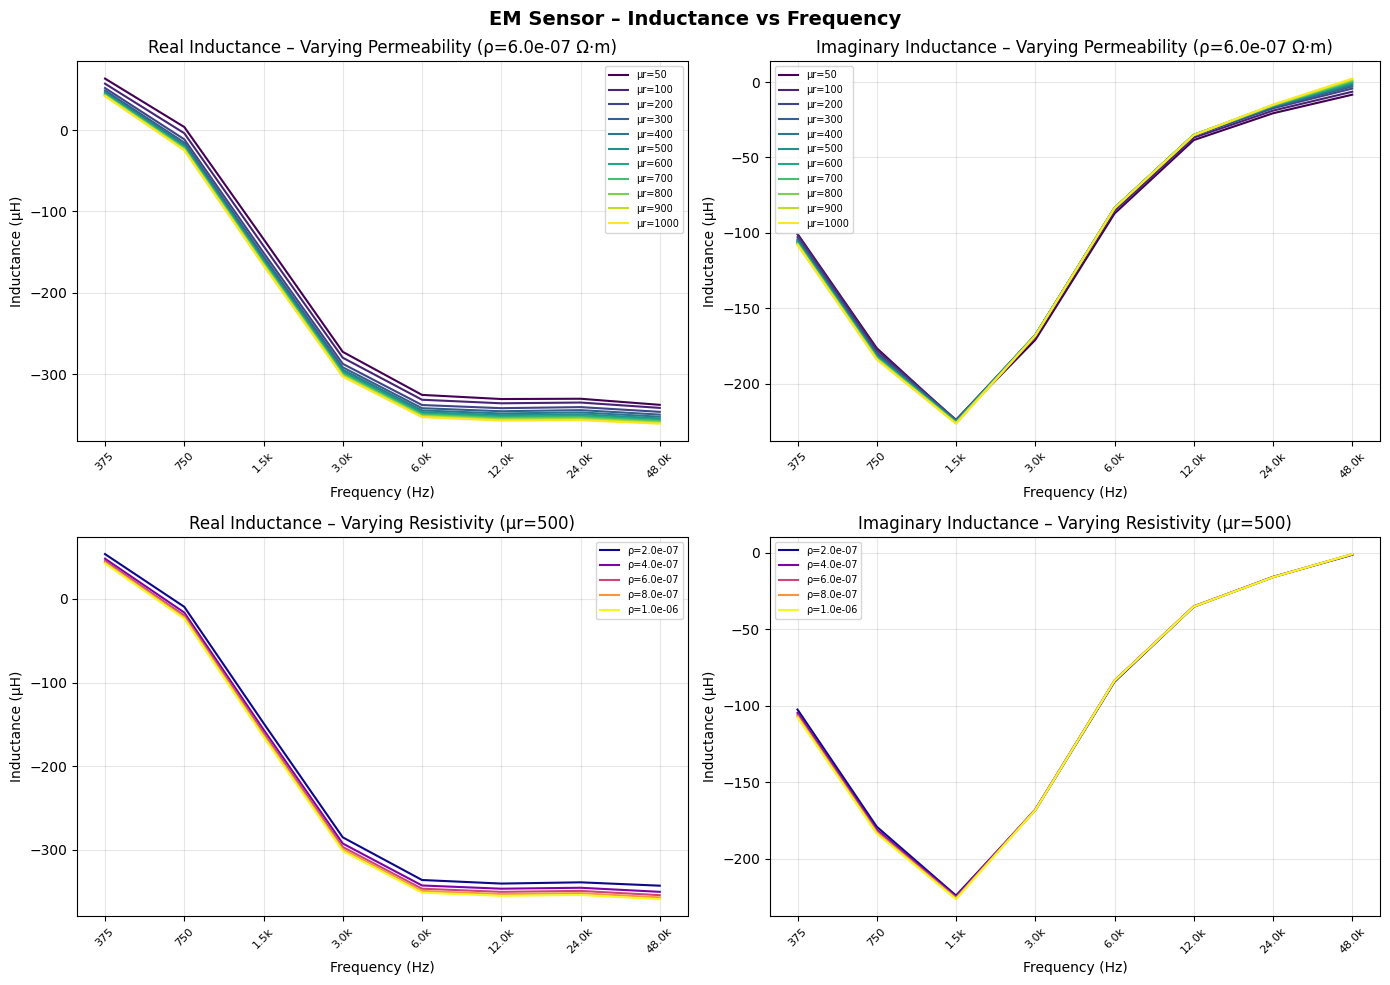

In [13]:
# Sorted unique parameter values across the simulation sweep
permeabilities = sorted(raw['permeability'].unique())
resistivities  = sorted(raw['resistivity'].unique())

# Choose fixed values for the "vary-one" subplots (middle value in each sweep)
res_fixed  = resistivities[len(resistivities) // 2]
perm_fixed = permeabilities[len(permeabilities) // 2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EM Sensor – Inductance vs Frequency', fontsize=14, fontweight='bold')

# --- Top row: vary permeability, fix resistivity ---
# Isolate rows with the fixed resistivity, then loop over all μr values.
subset1 = raw[raw['resistivity'] == res_fixed]
colors1  = plt.get_cmap('viridis')(np.linspace(0, 1, len(permeabilities)))

for i, perm in enumerate(permeabilities):
    g = subset1[subset1['permeability'] == perm].sort_values('frequency')
    # Scale H from H to μH for readability
    axes[0, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors1[i], label=f'μr={int(perm)}')
    axes[0, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors1[i], label=f'μr={int(perm)}')

axes[0, 0].set_title(f'Real Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')
axes[0, 1].set_title(f'Imaginary Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')

# --- Bottom row: vary resistivity, fix permeability ---
subset2 = raw[raw['permeability'] == perm_fixed]
colors2  = plt.get_cmap('plasma')(np.linspace(0, 1, len(resistivities)))

for i, res in enumerate(resistivities):
    g = subset2[subset2['resistivity'] == res].sort_values('frequency')
    axes[1, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')
    axes[1, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')

axes[1, 0].set_title(f'Real Inductance – Varying Resistivity (μr={int(perm_fixed)})')
axes[1, 1].set_title(f'Imaginary Inductance – Varying Resistivity (μr={int(perm_fixed)})')

# --- Shared formatting ---
# Use the exact simulated frequencies as x-ticks on a log scale.
freq_ticks  = sorted(raw['frequency'].unique())
freq_labels = [f'{f/1000:.1f}k' if f >= 1000 else str(int(f)) for f in freq_ticks]

for ax in axes.flat:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Inductance (μH)')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.set_xticks(freq_ticks)
    ax.set_xticklabels(freq_labels, rotation=45, fontsize=8)
    ax.get_xaxis().set_major_formatter(FixedFormatter(freq_labels))
    ax.minorticks_off()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir/'inductance_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Observations from the Plot:**
- **H_Real-Varying Permeability (top-left):** Starts positive at 375Hz and crosses zero somewhere between 375 and 750Hz, falls steeply till 3kHz, elbows at 6kHz, then flats out to 48kHz. Eddy currents start out weak at 375Hz and cannot generate magnetic field strong enough to oppose the signal but once eddy currents start getting stronger, it starts opposing the signal and H_real starts falling and at high frequencies, where skin depth becomes shallow, eddy currents completely shield the signal from penetrating deeper into the material. Now, the signal is restricted to the surface and its response remains constant, hence the flattening. 

- **H_Imaginary-Varying Permeability:** H_imag starts dropping and reaches minimum at 1.5kHz, then climbs to zero at higer frequencies. H_imag represents energy loss due to eddy currents so larger magnitude means more energy loss and vice-versa. Energy loss starts increasing as eddy currents grow stronger till it peaks at 1.5kHz and then drops at higher frequencies. This is because skin depth becomes shallow at high frequencies due to which eddy currents get restricted to surface of the material, and as a result energy loss decreases, hence the rise in H_imag.
Also a flip in the signal order is observed across 1.5kHz. Below 1.5KHz, higher μr means more energy loss, above 1.5kHz, it means less energy loss. Higher μr strengthens eddy currents (more loss) but also shrinks skin depth, confining eddy currents to thinner surface layer (less loss), and the second effect wins at higher frequencies where skin depth is small.

- **H_Imaginary-Varying Resistivity:** Line separation visible at low frequency but collapses above ~3kHz. H_imag therefore carries ρ information at low frequency only. Quantified in section 5.

- **H_Real-Varying Resistivity:** Same curve shape as H_real-varying permeability, and the curves separate consistently across the whole frequency range. ρ's effect on flux linkage is modest, but real. Quantified in section 5.

## 5. Variance Decomposition

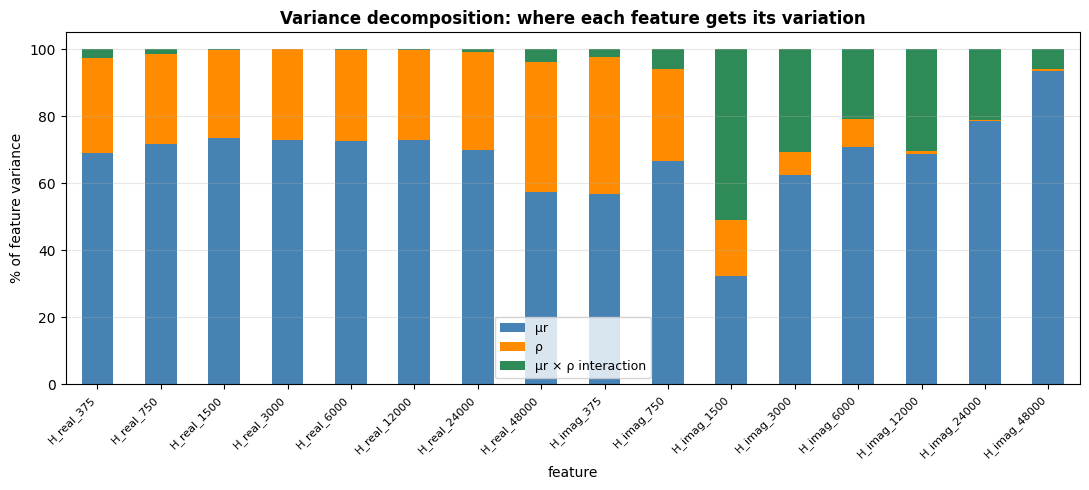

,mu_pct,rho_pct,interaction_pct
feature,,,
H_real_375,69.0,28.3,2.7
H_real_750,71.8,26.8,1.4
H_real_1500,73.6,26.1,0.3
H_real_3000,72.9,27.0,0.1
H_real_6000,72.7,27.2,0.1
H_real_12000,72.7,27.0,0.3
H_real_24000,69.9,29.1,0.9
H_real_48000,57.4,38.8,3.9
H_imag_375,56.8,41.0,2.3


In [8]:
freqs = sorted({int(c.split('_')[-1]) for c in wide_df.columns[2:]})
feature_cols = [f'{p}_{f}' for p in ('H_real', 'H_imag') for f in freqs]

rows = []
for c in feature_cols:
    # ddof=0 to calculate population variance
    tot = wide_df[c].var(ddof=0) 
    v_mu = wide_df.groupby('permeability')[c].mean().var(ddof=0)
    v_rho = wide_df.groupby('resistivity')[c].mean().var(ddof=0)
    rows.append((c, (v_mu/tot)*100, (v_rho/tot)*100, ((tot-v_mu-v_rho)/tot)*100))

var_split = pd.DataFrame(rows, columns=['feature', 'mu_pct', 'rho_pct', 'interaction_pct']).set_index('feature') 

fig, ax = plt.subplots(figsize=(11, 5))
var_split.plot(kind='bar', stacked=True, ax=ax,
               color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('% of feature variance')
ax.set_title('Variance decomposition: where each feature gets its variation', fontweight='bold')
ax.legend(['μr', 'ρ', 'μr × ρ interaction'], fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(fig_dir / 'variance_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

var_split.round(1)   

**Key Observations from Variance Decomposition:**
- Each feature's 55 values vary because only two things changed across the sweep: μr and ρ. The table above splits that variation into three parts: the share that tracksμr, the share that tracks ρ,  and the share that depends on both together (interaction). Because every μr x ρ combination is simulated exactly once with none missing, the split is exact. The three shares always total 100% and interaction can never come out negative.

- For the H_real channel, interaction is ≤ 3.9% at every frequency (mostly <1%). μr and ρ act on the real part almost independently.

- H_real carries ρ steadily across the whole spectrum, 26-29% of its variance at every frequency, rising to 38.8% at 48kHz. It is the most consistent ρ-bearing channel, only one still carrying ρ above 12kHz.

- H_imag's ρ share collapses with frequency, 41%(375Hz) -> 27.4%(750Hz) -> 16.6%(1500Hz) -> ≤1% from 12kHz upward. H_imag_375 has the largest ρ share of any feature in the dataset, while H_imag above 12kHz is effectively ρ-blind.

- The μr x ρ interaction lives almost entirely in H_imag, and peaks at 51% at 1500Hz. The same frequency where H_imag reaches its minimum and the permeability ordering flips. 1500Hz is where μr's two competing effects (stronger eddy currents -> more loss vs thinner skin depth -> less loss) balance, and which one dominates depends on ρ.

- This explains why 1500Hz looks like a weak channel in marginal measures. It has the lowest μr share (32.4) and a low ρ share (16.6), not because it is uninformative, but because over half of its variance is interaction, which marginal statistics cannot see.

- H_imag_48000 is the purest single target channel. 93.5% μr and 0.7% ρ, close to a direct permeability readout.

Caveat: These shares describe the sweep, not the sensor. μr was swept over 20x (50 -> 1000) and ρ only 5x (2e-7 -> 1e-6), so μr's share is inflated by the design. The table shows where each feature's variation comes from in the grid. It does not show how recoverable either target is. Also, each target share is a fraction of that feature'own variation, so equal percentage on two different features do not imply equal absolute target-driven variation. The features have different total variation.

## 6. Principal Component Analysis
PCA is a multivariate technique which transforms high-dimensional datasets into few uncorrelated variables(Principal Components) that capture the maximum variance from data. Here, PCA is used on the features isolated from targets to visualise global structures and identify which broad group of features are driving the variance in the data. 

In [9]:
from sklearn.decomposition import PCA

def compute_pca(input_data, data_label, feature_names, annotate_scores=False):
    print(f'For {data_label} data')
    pca = PCA(2)
    pc = pca.fit_transform(input_data)

    # percentage of variance each PC accounts for
    per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
    # One Label per PC
    labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

    # Scree Plot
    plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels, width=0.1)
    plt.ylabel('Percentage of Explained Variance')
    plt.xlabel('Principal Component')
    plt.title(f'Scree Plot({data_label} Data)')
    plt.show()

    # PCA Loadings
    pca_df = pd.DataFrame(pca.components_.T, index=feature_names, columns=labels)
    # PCA scores for each sample
    pca_scores = pd.DataFrame(pc, columns=labels, index=input_data.index 
                              if hasattr(input_data, 'index') else None)

    # PCA Score Plot
    plt.scatter(pca_scores.PC1, pca_scores.PC2)
    plt.title(f'PCA Score Plot ({data_label} Data)')
    plt.xlabel(f'PC1 ={per_var[0]}%')
    plt.ylabel(f'PC2 ={per_var[1]}%')
    if annotate_scores:
        for sample in pca_scores.index:
            plt.annotate(sample, (pca_scores.PC1.loc[sample], 
                                  pca_scores.PC2.loc[sample]), fontsize=6)
    plt.show()  

    # PCA Loading Plot
    plt.scatter(pca_df.PC1, pca_df.PC2)
    plt.title(f'PCA Loading Plot ({data_label} Data)')
    plt.xlabel(f'PC1 = {per_var[0]}%')
    plt.ylabel(f'PC2 = {per_var[1]}%')

    for sample in pca_df.index:
        plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]), fontsize=6)
    plt.show()  

    # Loading scores 
    sorted_loading_scores_pc1 = pca_df.PC1.reindex(pca_df.PC1.abs().sort_values(ascending=False).index)
    print(f'PC1 Loading Scores ({data_label} Data):\n{sorted_loading_scores_pc1}')
    sorted_loading_scores_pc2 = pca_df.PC2.reindex(pca_df.PC2.abs().sort_values(ascending=False).index)
    print(f'PC2 Loading Scores ({data_label} Data):\n{sorted_loading_scores_pc2}')


    return pca_df, pca_scores

For Scaled data


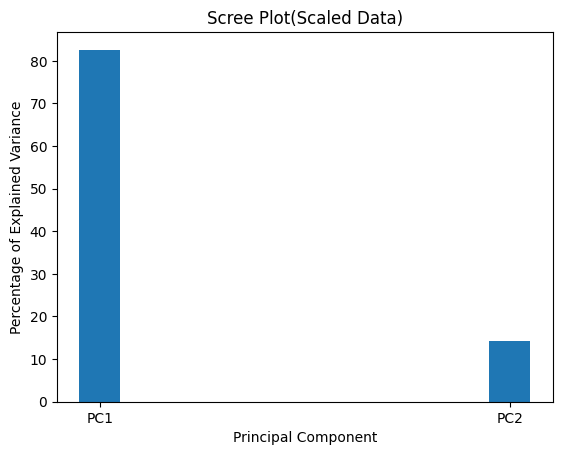

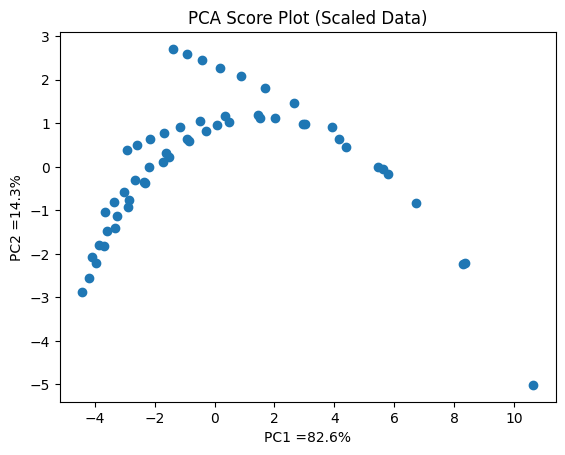

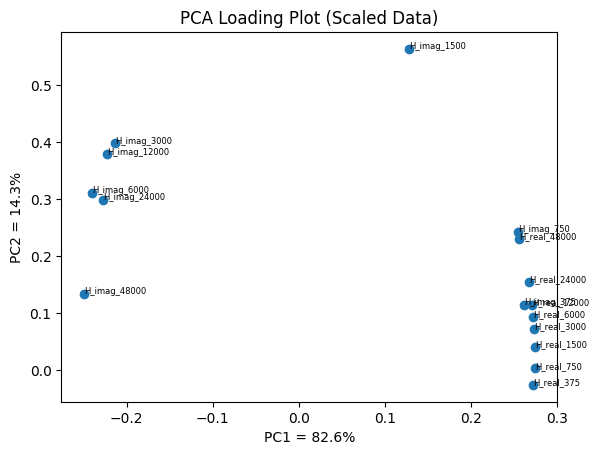

PC1 Loading Scores (Scaled Data):
H_real_1500     0.274101
H_real_750      0.274027
H_real_3000     0.273146
H_real_375      0.272469
H_real_6000     0.272190
H_real_12000    0.270885
H_real_24000    0.267287
H_imag_375      0.261824
H_real_48000    0.255556
H_imag_750      0.254763
H_imag_48000   -0.249702
H_imag_6000    -0.240565
H_imag_24000   -0.227475
H_imag_12000   -0.222402
H_imag_3000    -0.213045
H_imag_1500     0.128211
Name: PC1, dtype: float64
PC2 Loading Scores (Scaled Data):
H_imag_1500     0.563608
H_imag_3000     0.397651
H_imag_12000    0.378437
H_imag_6000     0.310223
H_imag_24000    0.298705
H_imag_750      0.242110
H_real_48000    0.229833
H_real_24000    0.154486
H_imag_48000    0.133227
H_real_12000    0.114607
H_imag_375      0.114450
H_real_6000     0.093561
H_real_3000     0.071992
H_real_1500     0.040266
H_real_375     -0.026226
H_real_750      0.002643
Name: PC2, dtype: float64


In [10]:
# Scaling data
from sklearn.preprocessing import StandardScaler

unscaled_data = wide_df.iloc[:, 2:]
features = unscaled_data.columns.to_list()

scaler = StandardScaler()
scaled_data= scaler.fit_transform(unscaled_data)

sc_loadings, sc_scores = compute_pca(scaled_data, 'Scaled', features)

In [11]:
# Score-target correlations: correlate PCA sample scores with the targets
targets = wide_df[['permeability', 'resistivity']].reset_index(drop=True)
scores_for_corr = sc_scores.reset_index(drop=True)

sc_score_target_corr = scores_for_corr.join(targets).corr(method='spearman')
print('PCA Score - Target Correlation (Spearman):')
sc_score_target_corr.loc[['PC1', 'PC2'], ['permeability', 'resistivity']]

PCA Score - Target Correlation (Spearman):


,permeability,resistivity
PC1,-0.844990,-0.486739
PC2,-0.122058,-0.480260


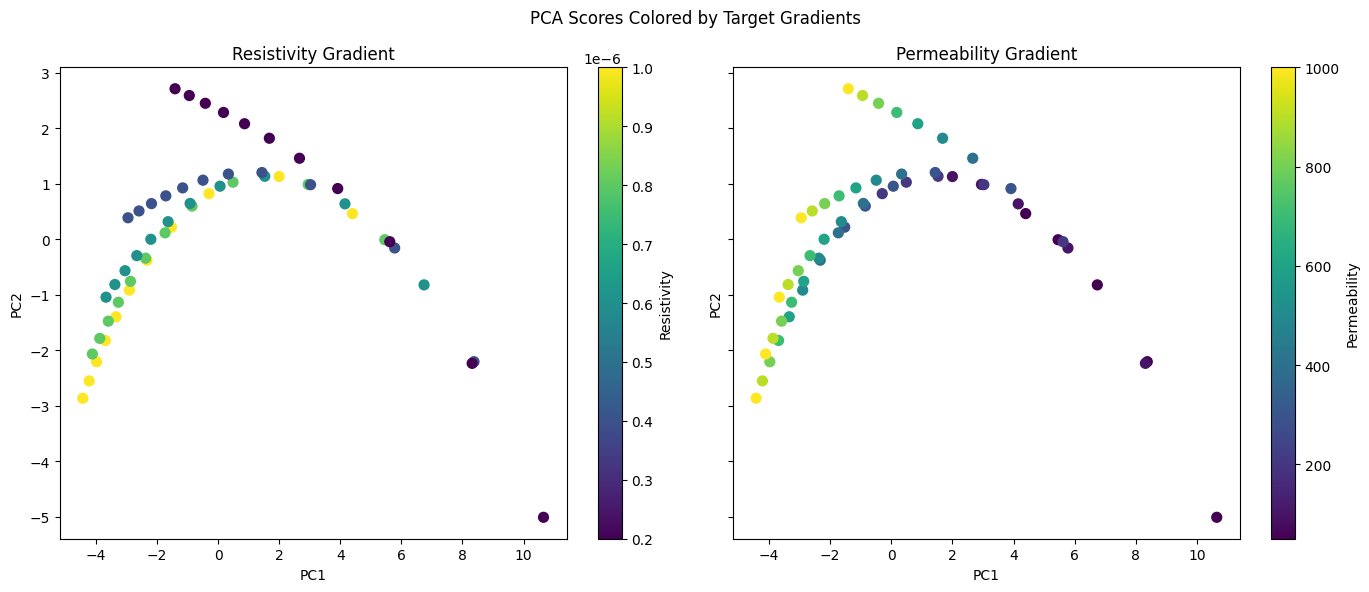

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

scatter_res = axes[0].scatter(
    sc_scores['PC1'], sc_scores['PC2'],
    c=wide_df['resistivity'], cmap='viridis', s=50
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Resistivity Gradient')
fig.colorbar(scatter_res, ax=axes[0], label='Resistivity')

scatter_perm = axes[1].scatter(
    sc_scores['PC1'], sc_scores['PC2'],
    c=wide_df['permeability'], cmap='viridis', s=50
)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Permeability Gradient')
fig.colorbar(scatter_perm, ax=axes[1], label='Permeability')

fig.suptitle('PCA Scores Colored by Target Gradients')
fig.tight_layout()
plt.show()

    
## Result Summary Scaled PCA
- PC1 and PC2 combined explain ~97% of variance in data.

- The PCA loadings shows both H_real and H_imag features across all frequencies in PC1 with similar and strong weights. H_real and H_imag load with opposite signs from 3kHZ upward, and with the same sign at 375, 750, and 1500 Hz.  H_imag weights are consistently smaller than H_real's.
(Principal component signs are arbitrary, so only the relative pattern is meaningful.)

- The sign flip of H_imag in PC1 is also observed in the inductance-frequency plot, where the order of permeability curves flip across 1.5kHz.

- PC2 is dominated by H_imag values, with H_real near-zero at most frequencies. 

- The PCA Score-Target Correlation: PC1-permeabililty = |0.84|, PC1-resistivity = |0.49|, PC2-permeabililty = |0.12|, PC2-resistivity = |0.48|. Magnitudes are quoted because PC signs are arbitrary. In this, all values came out negative.

- PC1 carries both targets. At |0.84| on μr and |0.49| on ρ, the dominant direction of feature variation is a mixture of the two parameters. μr cannot be read off PC1 without knowing ρ. This coupling of targets is the central difficulty of the inverse problem.

- The near-zero PC2-permeability correlation (|0.12|) does not mean permeability is absent from PC2. The score plot is a horseshoe: the 55 points form five nested arcs (one per ρ), with μr running along each arc. Following that arc, PC2 rises to a crest and falls again indicating that PC2 depends on μr non-monotonically, and a rank correlation scores this non-monotonicity close to zero by construction. Since the data is noise-free, all of PC2's variance is a function of the two targets. It is just that the correlation captures only the monotonic part of the dependence.

- The horseshoe effect: The arch appears when samples lie along a single dominant ordered gradient having a non-linear relationship with the features. This causes a linear PCA to bend the gradient into an arch because it can't represent a curved structure with linear components. Here the driving gradient is permeability, confirmed by the PCA Score - Permeability Gradient plot, where colour sweeps along the arc end to end. Resistivity instead varies across the arc, separating the five nested threads. Therefore, the horseshoe is consistent with a dominant nonlinear gradient and it's a known artifact of linear PCA straining against curved structure.

- Since both real and imaginary features bundle together into a single component, and two components cover more than 95% of variance in the data, the features are substantially redundant.

## Result Summary of EDA
- **No clean split between H_real and H_imag:** both targets act on both components at every frequency. The useful structure is frequency within each component, not component. 

- ρ's frequency structure differs sharply between the two components. H_imag carries ρ the most, out of any features, at 375Hz (41%) and is effectively ρ-blind above 12kHz (≤1%). H_real's composition stays steady at 27-29% throughout, rising to 38.8% only at 48kHz.

- The μr × ρ interaction is negligible in H_real but 51% in H_imag at 1500Hz. It is the same phenomenon as the order flip in H_imag.

- **The target-feature relation is non-linear:** saturating curves, the ordering flip at 1.5kHz, and PCA horseshoe all indicate the same thing.

- **The targets are entangled in the feature space:** PC1 mixes μr (|0.84|) and ρ (|0.49), so neither target can be read off the leading direction alone. This is the core difficulty of the inversion.

- **Caveats:** Variance shares are not comparable across targets, μr was swept over 20x and ρ only 5x, so the design contributes as much as the sensor. Comparisons across frequency within a feature are unaffected, And this describes the forward response only. How recoverable each target is from H is a modelling question.